In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# Create folders
os.makedirs("../report/plots", exist_ok=True)
os.makedirs("../data/exports", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Scorecard uses raw readable columns
scorecard_cols = [
    "loan_amnt",
    "int_rate",
    "grade",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "annual_inc",
    "revol_util",
    "emp_length",
    "pub_rec",
    "open_acc",
    "term",
    "purpose",
    "target"
]

df = pd.read_csv(
    "../data/processed/df_model_raw.csv",
    usecols=scorecard_cols,
    low_memory=False
)

print("Phase 6 scorecard dataset loaded successfully.")
print("Shape:", df.shape)
print("Default rate:", round(df["target"].mean() * 100, 2), "%")
print("\nTarget counts:")
print(df["target"].value_counts())

df.head()

Phase 6 scorecard dataset loaded successfully.
Shape: (1348099, 14)
Default rate: 19.98 %

Target counts:
target
0    1078739
1     269360
Name: count, dtype: int64


,loan_amnt,term,int_rate,grade,emp_length,annual_inc,purpose,dti,fico_range_low,fico_range_high,open_acc,pub_rec,revol_util,target
0,3600.0,36 months,13.99,C,10+ years,55000.0,debt_consolidation,5.91,675.0,679.0,7.0,0.0,29.7,0
1,24700.0,36 months,11.99,C,10+ years,65000.0,small_business,16.06,715.0,719.0,22.0,0.0,19.2,0
2,20000.0,60 months,10.78,B,10+ years,63000.0,home_improvement,10.78,695.0,699.0,6.0,0.0,56.2,0
3,10400.0,60 months,22.45,F,3 years,104433.0,major_purchase,25.37,695.0,699.0,12.0,0.0,64.5,0
4,11950.0,36 months,13.44,C,4 years,34000.0,debt_consolidation,10.20,690.0,694.0,5.0,0.0,68.4,0


## Phase 6 Scorecard Dataset

For the credit scorecard phase, the raw modeling dataset `df_model_raw.csv` was used because scorecard development requires readable borrower and loan features such as `grade`, `term`, `purpose`, `fico_range`, `dti`, and `revol_util`.

The dataset contains 1,348,099 completed loans with a default rate of approximately 19.98%. This dataset will be used to compute Weight of Evidence, Information Value, risk score points, risk tiers, and expected loss.

In [2]:
# Clean interest rate
df["int_rate"] = pd.to_numeric(
    df["int_rate"].astype(str).str.replace("%", "", regex=False).str.strip(),
    errors="coerce"
)

# Clean term
df["term"] = (
    df["term"]
    .astype(str)
    .str.strip()
    .str.replace(" months", "", regex=False)
)

# Create average FICO score
df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

# Clean emp_length into numeric years
df["emp_length_clean"] = (
    df["emp_length"]
    .astype(str)
    .str.replace("10+ years", "10", regex=False)
    .str.replace("< 1 year", "0", regex=False)
    .str.replace(" years", "", regex=False)
    .str.replace(" year", "", regex=False)
    .str.replace("nan", "", regex=False)
)

df["emp_length_clean"] = pd.to_numeric(df["emp_length_clean"], errors="coerce")

# Drop rows with missing values in important scorecard features
important_scorecard_cols = [
    "loan_amnt", "int_rate", "grade", "dti", "fico_avg",
    "annual_inc", "revol_util", "emp_length_clean",
    "pub_rec", "open_acc", "term", "purpose", "target"
]

print("Rows before cleaning:", df.shape[0])

df_sc = df.dropna(subset=important_scorecard_cols).copy()

print("Rows after cleaning:", df_sc.shape[0])
print("Default rate after cleaning:", round(df_sc["target"].mean() * 100, 2), "%")

df_sc[important_scorecard_cols].head()

Rows before cleaning: 1348099
Rows after cleaning: 1268686
Default rate after cleaning: 19.55 %


,loan_amnt,int_rate,grade,dti,fico_avg,annual_inc,revol_util,emp_length_clean,pub_rec,open_acc,term,purpose,target
0,3600.0,13.99,C,5.91,677.0,55000.0,29.7,10.0,0.0,7.0,36,debt_consolidation,0
1,24700.0,11.99,C,16.06,717.0,65000.0,19.2,10.0,0.0,22.0,36,small_business,0
2,20000.0,10.78,B,10.78,697.0,63000.0,56.2,10.0,0.0,6.0,60,home_improvement,0
3,10400.0,22.45,F,25.37,697.0,104433.0,64.5,3.0,0.0,12.0,60,major_purchase,0
4,11950.0,13.44,C,10.20,692.0,34000.0,68.4,4.0,0.0,5.0,36,debt_consolidation,0


## Scorecard Feature Preparation

Light cleaning was performed before WoE/IV calculation. Interest rate and loan term were cleaned, average FICO score was created, and employment length was converted into numeric years.

Rows with missing values in important scorecard features were removed to ensure clean binning and stable WoE calculation. After cleaning, the scorecard dataset contains 1,268,686 loans with a default rate of approximately 19.55%.

In [3]:
def compute_woe_iv(data, feature, target, bins=10, cat=False):
    """
    Compute Weight of Evidence and Information Value for one feature.
    target: 0 = Good loan, 1 = Bad/default loan
    """
    
    temp = data[[feature, target]].copy().dropna()
    
    total_good = (temp[target] == 0).sum()
    total_bad = (temp[target] == 1).sum()
    
    if cat:
        temp["bin"] = temp[feature].astype(str)
    else:
        temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")
    
    grouped = temp.groupby("bin")[target].agg(
        good=lambda x: (x == 0).sum(),
        bad=lambda x: (x == 1).sum()
    ).reset_index()
    
    grouped["total"] = grouped["good"] + grouped["bad"]
    grouped["default_rate"] = grouped["bad"] / grouped["total"]
    
    grouped["pct_good"] = grouped["good"] / total_good
    grouped["pct_bad"] = grouped["bad"] / total_bad
    
    # Avoid division by zero and log(0)
    grouped["pct_good"] = grouped["pct_good"].replace(0, 1e-6)
    grouped["pct_bad"] = grouped["pct_bad"].replace(0, 1e-6)
    
    grouped["WoE"] = np.log(grouped["pct_good"] / grouped["pct_bad"])
    grouped["IV_contribution"] = (grouped["pct_good"] - grouped["pct_bad"]) * grouped["WoE"]
    
    iv = grouped["IV_contribution"].sum()
    
    grouped["feature"] = feature
    grouped["IV"] = iv
    
    return grouped, iv

print("WoE/IV function created successfully.")

WoE/IV function created successfully.


In [4]:
numeric_features = {
    "fico_avg": 10,
    "int_rate": 10,
    "dti": 10,
    "loan_amnt": 10,
    "annual_inc": 10,
    "revol_util": 10,
    "emp_length_clean": 8,
    "open_acc": 8,
    "pub_rec": 5
}

categorical_features = ["grade", "term", "purpose"]

iv_summary = []
woe_tables = {}

# Numeric features
for feature, bins in numeric_features.items():
    woe_table, iv = compute_woe_iv(
        df_sc,
        feature=feature,
        target="target",
        bins=bins,
        cat=False
    )
    
    iv_summary.append({
        "feature": feature,
        "IV": round(iv, 4),
        "type": "numeric"
    })
    
    woe_tables[feature] = woe_table

# Categorical features
for feature in categorical_features:
    woe_table, iv = compute_woe_iv(
        df_sc,
        feature=feature,
        target="target",
        cat=True
    )
    
    iv_summary.append({
        "feature": feature,
        "IV": round(iv, 4),
        "type": "categorical"
    })
    
    woe_tables[feature] = woe_table

iv_df = pd.DataFrame(iv_summary).sort_values("IV", ascending=False)

# Add predictive power label
def iv_power(iv):
    if iv < 0.02:
        return "Useless"
    elif iv < 0.10:
        return "Weak"
    elif iv < 0.30:
        return "Medium"
    elif iv < 0.50:
        return "Strong"
    else:
        return "Very Strong / Check Leakage"

iv_df["predictive_power"] = iv_df["IV"].apply(iv_power)

iv_df.to_csv("../report/iv_summary.csv", index=False)

print("IV summary:")
iv_df

IV summary:


,feature,IV,type,predictive_power
9,grade,0.4749,categorical,Strong
1,int_rate,0.4636,numeric,Strong
10,term,0.1860,categorical,Medium
0,fico_avg,0.1270,numeric,Medium
2,dti,0.0713,numeric,Weak
3,loan_amnt,0.0427,numeric,Weak
5,revol_util,0.0257,numeric,Weak
4,annual_inc,0.0244,numeric,Weak
11,purpose,0.0209,categorical,Weak
7,open_acc,0.0065,numeric,Useless


### Information Value Summary

Information Value was calculated for key scorecard features to measure their predictive power for loan default.

The strongest features are `grade` and `int_rate`, with IV values of 0.4749 and 0.4636 respectively. Both are strong predictors of default risk. `term` and `fico_avg` show medium predictive power, while variables such as `dti`, `loan_amnt`, `revol_util`, `annual_inc`, and `purpose` show weak predictive power.

Loan grade is included in the scorecard because it is a business-approved risk indicator assigned before loan outcome is known. It is not direct target leakage, but because it summarizes borrower risk, its high IV should be documented carefully.

For scorecard development, features with IV above 0.10 will be selected because they provide sufficient predictive power while keeping the scorecard simple and interpretable.

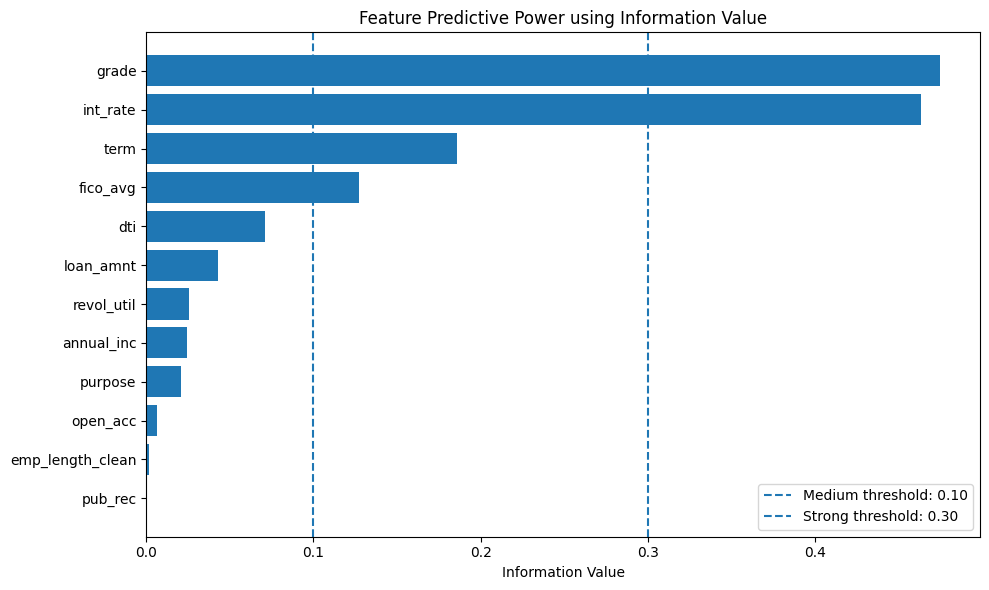

In [5]:
iv_plot_df = iv_df.sort_values("IV", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(iv_plot_df["feature"], iv_plot_df["IV"])

plt.axvline(0.10, linestyle="--", linewidth=1.5, label="Medium threshold: 0.10")
plt.axvline(0.30, linestyle="--", linewidth=1.5, label="Strong threshold: 0.30")

plt.xlabel("Information Value")
plt.title("Feature Predictive Power using Information Value")
plt.legend()
plt.tight_layout()

plt.savefig("../report/plots/15_iv_feature_importance.png", bbox_inches="tight")
plt.show()

In [6]:
scorecard_features = iv_df[iv_df["IV"] >= 0.10]["feature"].tolist()

print("Selected scorecard features:")
print(scorecard_features)

print("\nNumber of selected features:", len(scorecard_features))

Selected scorecard features:
['grade', 'int_rate', 'term', 'fico_avg']

Number of selected features: 4


## Scorecard Feature Selection

Features with Information Value greater than or equal to 0.10 were selected for scorecard development. This threshold keeps the scorecard interpretable while retaining features with meaningful predictive power.

The selected scorecard features are:

- `grade`
- `int_rate`
- `term`
- `fico_avg`

These features represent loan risk grade, pricing risk, repayment duration, and borrower credit quality.

In [7]:
def apply_woe(data, feature, woe_table, cat=False):
    """
    Apply WoE mapping to a feature.
    """
    temp = data[feature].copy()
    
    if cat:
        woe_map = dict(zip(woe_table["bin"].astype(str), woe_table["WoE"]))
        return temp.astype(str).map(woe_map)
    
    else:
        # Extract interval bins from WoE table
        intervals = woe_table["bin"].tolist()
        woe_values = woe_table["WoE"].tolist()
        
        result = pd.Series(index=temp.index, dtype=float)
        
        for interval, woe in zip(intervals, woe_values):
            result[temp.between(interval.left, interval.right, inclusive="right")] = woe
        
        return result


# Build WoE-transformed dataset
X_woe = pd.DataFrame(index=df_sc.index)

for feature in scorecard_features:
    is_cat = feature in categorical_features
    X_woe[feature + "_woe"] = apply_woe(
        df_sc,
        feature,
        woe_tables[feature],
        cat=is_cat
    )

X_woe["target"] = df_sc["target"].values

print("WoE dataset shape before dropping missing:", X_woe.shape)
print("Missing values:")
print(X_woe.isnull().sum())

X_woe = X_woe.dropna()

print("\nWoE dataset shape after dropping missing:", X_woe.shape)
print("\nDefault rate:", round(X_woe["target"].mean() * 100, 2), "%")

X_woe.head()

WoE dataset shape before dropping missing: (1268686, 5)
Missing values:
grade_woe       0
int_rate_woe    0
term_woe        0
fico_avg_woe    0
target          0
dtype: int64

WoE dataset shape after dropping missing: (1268686, 5)

Default rate: 19.55 %


,grade_woe,int_rate_woe,term_woe,fico_avg_woe,target
0,-0.147028,-0.202582,0.284389,-0.226242,0
1,-0.147028,0.187000,0.284389,0.301037,0
2,0.488204,0.315747,-0.664250,0.005145,0
3,-1.204353,-0.986873,-0.664250,0.005145,0
4,-0.147028,-0.010367,0.284389,-0.074281,0


## WoE-transformed Dataset

The selected scorecard features were transformed into Weight of Evidence values. The final WoE dataset contains four transformed features: `grade_woe`, `int_rate_woe`, `term_woe`, and `fico_avg_woe`.

There are no missing values after WoE transformation. The target default rate remains approximately 19.55%, so the scorecard dataset is ready for logistic regression modeling.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, f1_score, precision_score, recall_score

# Separate features and target
X_sc = X_woe.drop(columns=["target"])
y_sc = X_woe["target"]

# Train-test split
X_train_sc, X_test_sc, y_train_sc, y_test_sc = train_test_split(
    X_sc,
    y_sc,
    test_size=0.2,
    random_state=42,
    stratify=y_sc
)

# Train logistic regression on WoE features
scorecard_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

scorecard_model.fit(X_train_sc, y_train_sc)

# Predictions
scorecard_probs = scorecard_model.predict_proba(X_test_sc)[:, 1]
scorecard_preds = (scorecard_probs >= 0.5).astype(int)

# Metrics
scorecard_auc = roc_auc_score(y_test_sc, scorecard_probs)
scorecard_f1 = f1_score(y_test_sc, scorecard_preds)
scorecard_precision = precision_score(y_test_sc, scorecard_preds)
scorecard_recall = recall_score(y_test_sc, scorecard_preds)

fpr_sc, tpr_sc, thresholds_sc = roc_curve(y_test_sc, scorecard_probs)
scorecard_ks = max(tpr_sc - fpr_sc)
scorecard_gini = 2 * scorecard_auc - 1

print("Scorecard Logistic Regression Results")
print("AUC-ROC:", round(scorecard_auc, 4))
print("KS Stat:", round(scorecard_ks, 4))
print("Gini:", round(scorecard_gini, 4))
print("F1 Score:", round(scorecard_f1, 4))
print("Precision:", round(scorecard_precision, 4))
print("Recall:", round(scorecard_recall, 4))

print("\nClassification Report:")
print(classification_report(y_test_sc, scorecard_preds, target_names=["Good Loan", "Default"]))

Scorecard Logistic Regression Results
AUC-ROC: 0.6972
KS Stat: 0.2846
Gini: 0.3943
F1 Score: 0.4109
Precision: 0.2938
Recall: 0.683

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.89      0.60      0.72    204131
     Default       0.29      0.68      0.41     49607

    accuracy                           0.62    253738
   macro avg       0.59      0.64      0.56    253738
weighted avg       0.77      0.62      0.66    253738



## Scorecard Logistic Regression Results

A logistic regression model was trained on the WoE-transformed scorecard features. This model is intentionally simpler and more interpretable than the XGBoost model from Phase 5.

The scorecard model achieved an AUC-ROC of 0.6972, KS statistic of 0.2846, and Gini score of 0.3943. The default recall is 68.30%, meaning the model identifies a large portion of actual defaulters using only four interpretable scorecard features.

Although the scorecard model has slightly lower predictive power than XGBoost, it is more explainable, easier to audit, and suitable for building a credit scorecard table with points assigned to each feature bin.

In [9]:
# Scorecard scaling parameters
PDO = 20
Target_Score = 600
Target_Odds = 1.0

Factor = PDO / np.log(2)
Offset = Target_Score - Factor * np.log(Target_Odds)

print("Factor:", round(Factor, 4))
print("Offset:", round(Offset, 4))

# Extract coefficients
coefficients = scorecard_model.coef_[0]
intercept = scorecard_model.intercept_[0]
n_features = len(scorecard_features)

scorecard_rows = []

for i, feature_woe in enumerate(X_sc.columns):
    feature = feature_woe.replace("_woe", "")
    coefficient = coefficients[i]
    woe_table = woe_tables[feature]
    
    for _, row in woe_table.iterrows():
        points = -(
            coefficient * row["WoE"] + intercept / n_features
        ) * Factor + Offset / n_features
        
        scorecard_rows.append({
            "feature": feature,
            "bin": str(row["bin"]),
            "good": int(row["good"]),
            "bad": int(row["bad"]),
            "default_rate_pct": round(row["default_rate"] * 100, 2),
            "WoE": round(row["WoE"], 4),
            "coefficient": round(coefficient, 4),
            "points": round(points, 1),
            "IV": round(row["IV"], 4)
        })

scorecard_table = pd.DataFrame(scorecard_rows)

scorecard_table.to_csv("../report/scorecard_table.csv", index=False)

print("Scorecard table saved.")
print("Rows:", scorecard_table.shape[0])

scorecard_table.head(20)

Factor: 28.8539
Offset: 600.0
Scorecard table saved.
Rows: 29


,feature,bin,good,bad,default_rate_pct,WoE,coefficient,points,IV
0,grade,A,209619,12801,5.76,1.3811,-0.4920,169.6,0.4749
1,grade,B,322141,48046,12.98,0.4882,-0.4920,156.9,0.4749
2,grade,C,280398,78934,21.97,-0.1470,-0.4920,147.9,0.4749
3,grade,D,132182,56366,29.89,-0.5623,-0.4920,142.0,0.4749
4,grade,E,54909,33822,38.12,-0.9301,-0.4920,136.8,0.4749
5,grade,F,16906,13700,44.76,-1.2044,-0.4920,132.9,0.4749
6,grade,G,4496,4366,49.27,-1.3853,-0.4920,130.3,0.4749
7,int_rate,"(5.308999999999999, 7.39]",121856,5893,4.61,1.6144,-0.3210,165.0,0.4636
8,int_rate,"(7.39, 8.9]",118268,10517,8.17,1.0053,-0.3210,159.3,0.4636
9,int_rate,"(8.9, 10.49]",114466,15194,11.72,0.6048,-0.3210,155.6,0.4636


## Scorecard Points Table

The scorecard table converts WoE-transformed logistic regression outputs into interpretable score points. Each feature bin receives a score contribution based on its WoE value and model coefficient.

The table shows that lower-risk bins receive higher points. For example, Grade A loans receive around 169.6 points, while Grade G loans receive around 130.3 points. Similarly, borrowers with lower interest rates receive higher points than borrowers with higher interest rates.

This scorecard table is one of the main deliverables of Phase 6 because it translates model behavior into a transparent, auditable, and business-readable scoring system.

In [10]:
# Predict default probability for all scorecard borrowers
all_pd = scorecard_model.predict_proba(X_sc)[:, 1]

# Convert probability to log odds
# odds_good_bad = probability of good / probability of bad
odds_good_bad = (1 - all_pd) / all_pd

# Convert odds into score
raw_scores = Offset + Factor * np.log(odds_good_bad)

# Clip scores to 300-850 scale
credit_scores = np.clip(raw_scores, 300, 850).round(0).astype(int)

# Add to X_woe
X_woe["PD"] = all_pd
X_woe["credit_score"] = credit_scores

print("Credit scores assigned successfully.")
print("Score summary:")
print(pd.Series(credit_scores).describe())

print("\nAverage score by outcome:")
print(X_woe.groupby("target")["credit_score"].mean())

Credit scores assigned successfully.
Score summary:
count    1.268686e+06
mean     6.049429e+02
std      2.243253e+01
min      5.570000e+02
25%      5.880000e+02
50%      6.030000e+02
75%      6.180000e+02
max      6.500000e+02
dtype: float64

Average score by outcome:
target
0    607.927308
1    592.662346
Name: credit_score, dtype: float64


## Credit Score Assignment

Credit scores were assigned to all borrowers using the scorecard logistic regression model. The scores were mapped using odds-based scorecard scaling and clipped to a 300–850 credit score range.

The score distribution ranges from 557 to 650, with an average score of around 605. Good loans have an average score of approximately 607.93, while default loans have an average score of approximately 592.66.

This confirms that the scorecard is directionally valid because lower-risk borrowers receive higher scores and higher-risk borrowers receive lower scores.

In [11]:
score_percentiles = pd.Series(credit_scores).quantile([0.20, 0.50, 0.80])

print("Score percentiles:")
print(score_percentiles)

Score percentiles:
0.2    586.0
0.5    603.0
0.8    623.0
dtype: float64


In [12]:
def assign_risk_tier(score):
    if score >= 623:
        return "Low Risk"
    elif score >= 586:
        return "Medium Risk"
    else:
        return "High Risk"

X_woe["risk_tier"] = X_woe["credit_score"].apply(assign_risk_tier)

tier_summary = X_woe.groupby("risk_tier").agg(
    total_loans=("target", "count"),
    defaults=("target", "sum"),
    default_rate=("target", "mean"),
    avg_score=("credit_score", "mean"),
    avg_pd=("PD", "mean")
).reset_index()

tier_summary["default_rate_pct"] = (tier_summary["default_rate"] * 100).round(2)
tier_summary["avg_score"] = tier_summary["avg_score"].round(0)
tier_summary["avg_pd_pct"] = (tier_summary["avg_pd"] * 100).round(2)

tier_order = ["Low Risk", "Medium Risk", "High Risk"]
tier_summary["risk_tier"] = pd.Categorical(
    tier_summary["risk_tier"],
    categories=tier_order,
    ordered=True
)

tier_summary = tier_summary.sort_values("risk_tier")

print("Risk tier summary:")
tier_summary

Risk tier summary:


,risk_tier,total_loans,defaults,default_rate,avg_score,avg_pd,default_rate_pct,avg_pd_pct
1,Low Risk,256119,15898,0.062073,639.0,0.210163,6.21,21.02
2,Medium Risk,768142,141084,0.183669,603.0,0.471333,18.37,47.13
0,High Risk,244425,91053,0.372519,574.0,0.706600,37.25,70.66


## Risk Tier Segmentation

Borrowers were segmented into Low Risk, Medium Risk, and High Risk tiers using score percentiles from the score distribution.

The scorecard creates clear separation between borrower risk groups. Low Risk borrowers have an actual default rate of around 6.21%, Medium Risk borrowers have a default rate of around 18.37%, and High Risk borrowers have a default rate of around 37.25%.

This shows that the credit scorecard successfully ranks borrowers by risk. High Risk borrowers default almost six times more often than Low Risk borrowers, making this segmentation useful for approval strategy, manual review, and lending policy decisions.

The model-predicted PD values are higher than actual default rates because class weighting was used during logistic regression training. Therefore, actual observed default rates by tier should be emphasized for business interpretation.

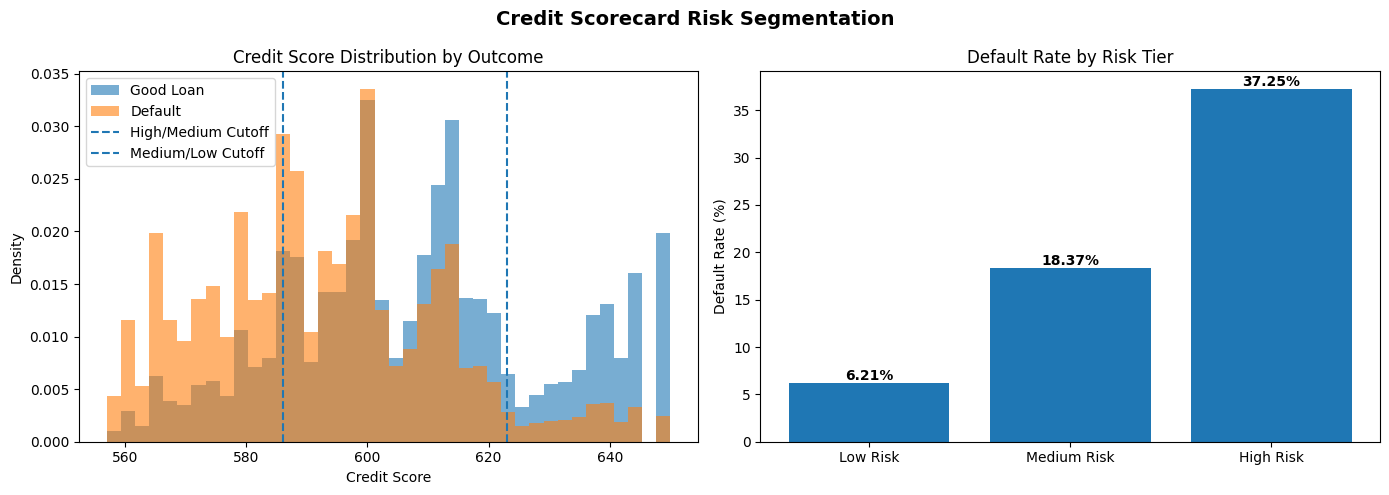

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by actual outcome
axes[0].hist(
    X_woe[X_woe["target"] == 0]["credit_score"],
    bins=40,
    alpha=0.6,
    label="Good Loan",
    density=True
)

axes[0].hist(
    X_woe[X_woe["target"] == 1]["credit_score"],
    bins=40,
    alpha=0.6,
    label="Default",
    density=True
)

axes[0].axvline(586, linestyle="--", linewidth=1.5, label="High/Medium Cutoff")
axes[0].axvline(623, linestyle="--", linewidth=1.5, label="Medium/Low Cutoff")

axes[0].set_title("Credit Score Distribution by Outcome")
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Density")
axes[0].legend()

# Default rate by tier
axes[1].bar(
    tier_summary["risk_tier"].astype(str),
    tier_summary["default_rate_pct"]
)

axes[1].set_title("Default Rate by Risk Tier")
axes[1].set_ylabel("Default Rate (%)")

for i, value in enumerate(tier_summary["default_rate_pct"]):
    axes[1].text(i, value, f"{value:.2f}%", ha="center", va="bottom", fontweight="bold")

plt.suptitle("Credit Scorecard Risk Segmentation", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("../report/plots/16_score_distribution_and_risk_tiers.png", bbox_inches="tight")
plt.show()

## Score Distribution and Risk Tier Analysis

The score distribution shows that good loans generally have higher credit scores, while default loans are more concentrated toward lower scores. Although there is some overlap between good and bad loans, the scorecard is able to rank borrowers meaningfully by risk.

The risk tier chart shows clear default separation across the three tiers. Low Risk borrowers have a default rate of approximately 6.21%, Medium Risk borrowers have a default rate of approximately 18.37%, and High Risk borrowers have a default rate of approximately 37.25%.

This confirms that the scorecard segmentation is business-useful. High Risk borrowers default almost six times more often than Low Risk borrowers, which can support approval rules, manual review decisions, and pricing strategy.

In [14]:
# Add loan amount for exposure calculation
X_woe["loan_amnt"] = df_sc.loc[X_woe.index, "loan_amnt"].values

# Expected Loss components
LGD = 0.60  # Loss Given Default assumption: 60%
X_woe["EAD"] = X_woe["loan_amnt"]  # Exposure at Default
X_woe["expected_loss"] = X_woe["PD"] * LGD * X_woe["EAD"]

# Portfolio-level expected loss
total_exposure = X_woe["EAD"].sum()
total_expected_loss = X_woe["expected_loss"].sum()
expected_loss_rate = total_expected_loss / total_exposure * 100

print("Portfolio Expected Loss Summary")
print("Total exposure:", f"${total_exposure:,.0f}")
print("Total expected loss:", f"${total_expected_loss:,.0f}")
print("Expected loss rate:", f"{expected_loss_rate:.2f}%")
print("Assumed LGD:", f"{LGD * 100:.0f}%")

Portfolio Expected Loss Summary
Total exposure: $18,511,656,000
Total expected loss: $5,356,734,056
Expected loss rate: 28.94%
Assumed LGD: 60%


## Portfolio Expected Loss

Expected Loss was calculated using the formula:

`Expected Loss = PD × LGD × EAD`

where PD is the model-predicted probability of default, LGD is assumed to be 60%, and EAD is the loan amount.

The total portfolio exposure is approximately $18.51B and the model-based expected loss is approximately $5.36B, giving an expected loss rate of around 28.94%.

Because the scorecard logistic regression model was trained with class weighting, the predicted probabilities are not fully calibrated. Therefore, the expected loss output should be interpreted as a model-based risk estimate, while observed default rates by tier should also be used for business interpretation.

In [15]:
tier_el = X_woe.groupby("risk_tier").agg(
    total_loans=("EAD", "count"),
    total_exposure=("EAD", "sum"),
    total_expected_loss=("expected_loss", "sum"),
    avg_pd=("PD", "mean"),
    actual_default_rate=("target", "mean")
).reset_index()

tier_el["exposure_pct"] = tier_el["total_exposure"] / tier_el["total_exposure"].sum() * 100
tier_el["expected_loss_pct"] = tier_el["total_expected_loss"] / tier_el["total_expected_loss"].sum() * 100
tier_el["expected_loss_rate"] = tier_el["total_expected_loss"] / tier_el["total_exposure"] * 100
tier_el["avg_pd_pct"] = tier_el["avg_pd"] * 100
tier_el["actual_default_rate_pct"] = tier_el["actual_default_rate"] * 100

tier_order = ["Low Risk", "Medium Risk", "High Risk"]
tier_el["risk_tier"] = pd.Categorical(
    tier_el["risk_tier"],
    categories=tier_order,
    ordered=True
)

tier_el = tier_el.sort_values("risk_tier")

display_cols = [
    "risk_tier",
    "total_loans",
    "total_exposure",
    "exposure_pct",
    "total_expected_loss",
    "expected_loss_pct",
    "expected_loss_rate",
    "avg_pd_pct",
    "actual_default_rate_pct"
]

tier_el[display_cols].round(2)

,risk_tier,total_loans,total_exposure,exposure_pct,total_expected_loss,expected_loss_pct,expected_loss_rate,avg_pd_pct,actual_default_rate_pct
1,Low Risk,256119,3.582798e+09,19.35,4.522571e+08,8.44,12.62,21.02,6.21
2,Medium Risk,768142,1.034771e+10,55.90,2.949511e+09,55.06,28.50,47.13,18.37
0,High Risk,244425,4.581151e+09,24.75,1.954966e+09,36.50,42.67,70.66,37.25


## Expected Loss by Risk Tier

Expected Loss was also analyzed across the three risk tiers.

Low Risk borrowers represent around 19.35% of total exposure but only 8.44% of expected loss. High Risk borrowers represent around 24.75% of total exposure but contribute around 36.50% of expected loss.

This shows a disproportionate concentration of risk in the High Risk segment. The High Risk tier also has an observed default rate of 37.25%, compared to only 6.21% for the Low Risk tier.

This finding supports the business value of the scorecard. The model can help lenders identify high-risk borrowers, apply stricter review rules, adjust pricing, or reduce exposure to risky segments.

In [16]:
tier_el.to_csv("../data/exports/expected_loss_by_tier.csv", index=False)

X_woe[[
    "credit_score",
    "risk_tier",
    "PD",
    "EAD",
    "expected_loss",
    "target"
]].to_csv("../data/exports/borrower_scores.csv", index=False)

print("Saved expected loss outputs:")
print("data/exports/expected_loss_by_tier.csv")
print("data/exports/borrower_scores.csv")

Saved expected loss outputs:
data/exports/expected_loss_by_tier.csv
data/exports/borrower_scores.csv


In [17]:
# Save scorecard artifacts locally

joblib.dump(scorecard_model, "../models/scorecard_model.pkl")
joblib.dump(woe_tables, "../models/woe_tables.pkl")
joblib.dump(scorecard_features, "../models/scorecard_features.pkl")

# Save report files again
scorecard_table.to_csv("../report/scorecard_table.csv", index=False)
iv_df.to_csv("../report/iv_summary.csv", index=False)
tier_el.to_csv("../report/expected_loss_by_tier_summary.csv", index=False)

print("Saved scorecard artifacts:")
print("models/scorecard_model.pkl")
print("models/woe_tables.pkl")
print("models/scorecard_features.pkl")
print("report/scorecard_table.csv")
print("report/iv_summary.csv")
print("report/expected_loss_by_tier_summary.csv")

Saved scorecard artifacts:
models/scorecard_model.pkl
models/woe_tables.pkl
models/scorecard_features.pkl
report/scorecard_table.csv
report/iv_summary.csv
report/expected_loss_by_tier_summary.csv
